# Basic Test

In [1]:
# Add project root to Python path
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# Install dependencies if needed (uncomment if running for first time)
# !pip install scipy statsmodels pandas numpy matplotlib tqdm

# Updated imports for new repository structure
from src.imports import *
from src.agents import RecommenderAgent, RecommendedAgent
from src.environment import ExogenousRewardEnvironment
from src.simulations import run_recommender_simulation
from src.plotting_utils import (
    plot_full_results, 
    plot_reward_statistics, 
    plot_sensitivity,
    plot_initial_vs_final_qvalues,
    plot_learning_summary
)
from src.reward_modulators import MoodSwings, ReceptorModulator, NoveltyModulator
from src.stationarity_analysis import *

# Environment Testing

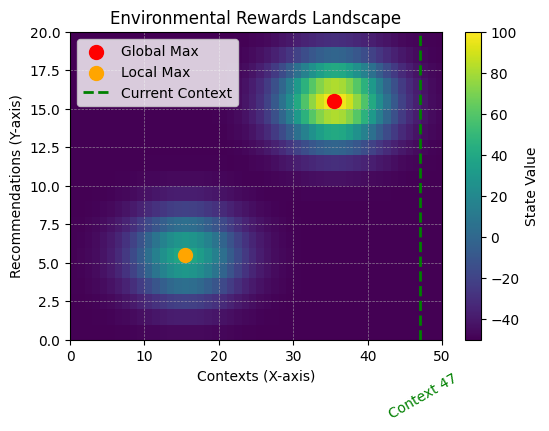

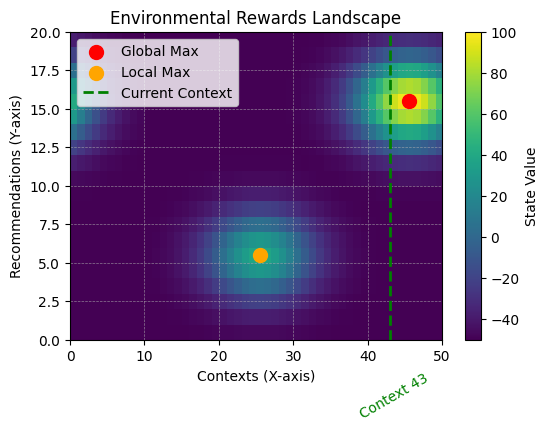

[47, 45, 42, 37, 41, 37, 32, 34, 36, 39, 43]


In [2]:
ere = ExogenousRewardEnvironment()
ere.do_gaussian_smoothing()
ere.visualize_landscape(mark_context=True)
for steps in (range(10)):
  ere.step_context()
  ere.shift_environment_right()
ere.visualize_landscape(mark_context=True)
print(ere.get_context_history())

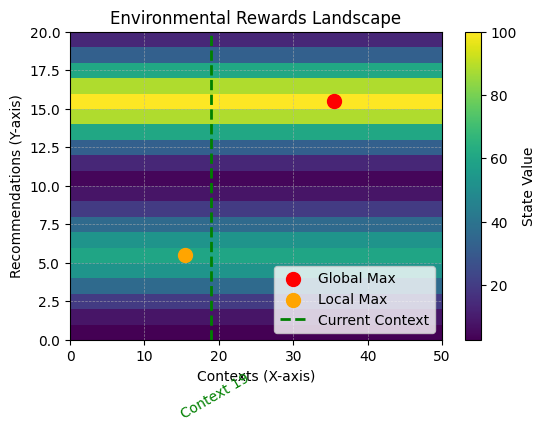

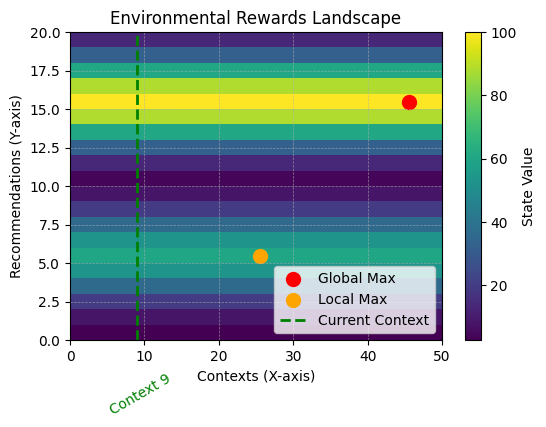

[19, 16, 12, 8, 5, 3, 4, 6, 8, 4, 9]


In [3]:
ere = ExogenousRewardEnvironment()
ere.do_rows_gaussian_smoothing()
ere.visualize_landscape(mark_context=True)
for steps in (range(10)):
  ere.step_context()
  ere.shift_environment_right()
ere.visualize_landscape(mark_context=True)
print(ere.get_context_history())

# Simulation Testing

## Stationary, Initiation, No Modulation

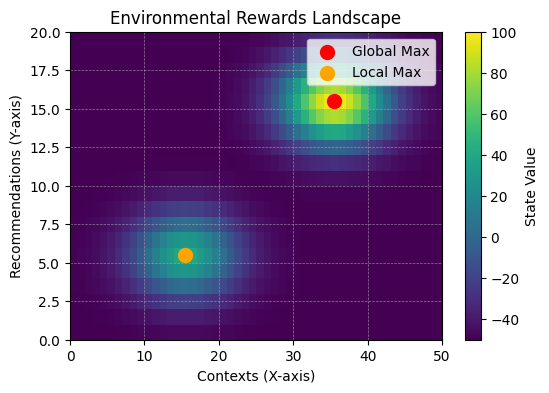

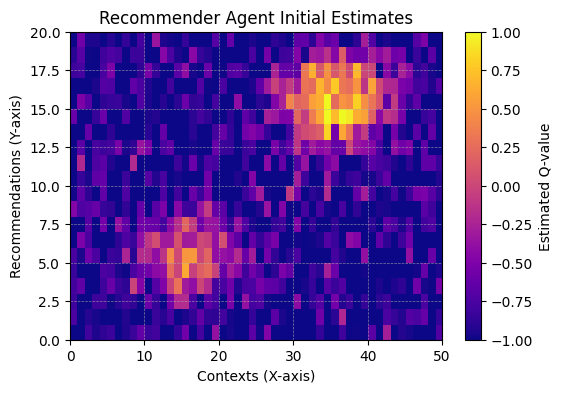

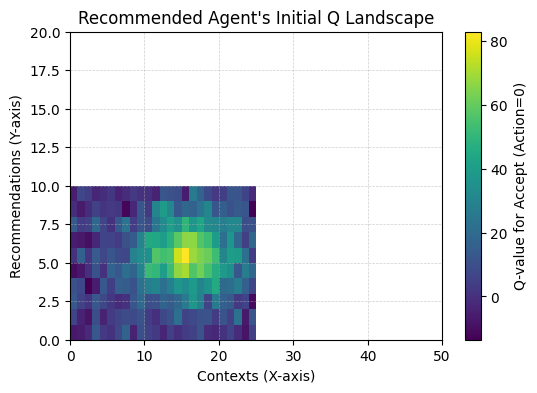

Running Simulation: 100%|██████████| 500000/500000 [00:30<00:00, 16479.74it/s]


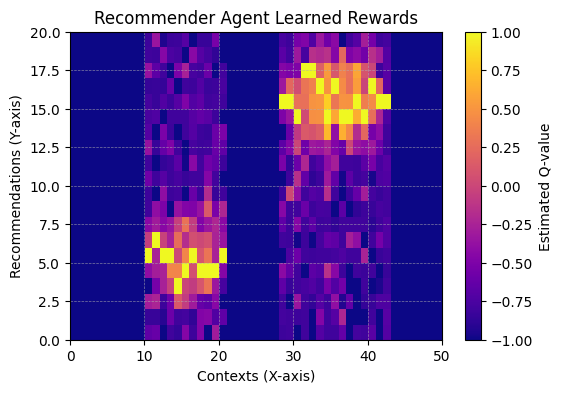

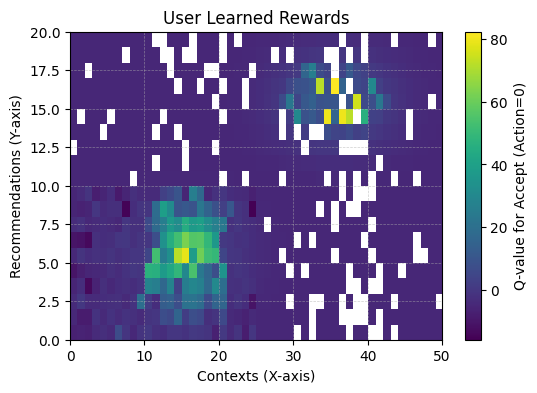

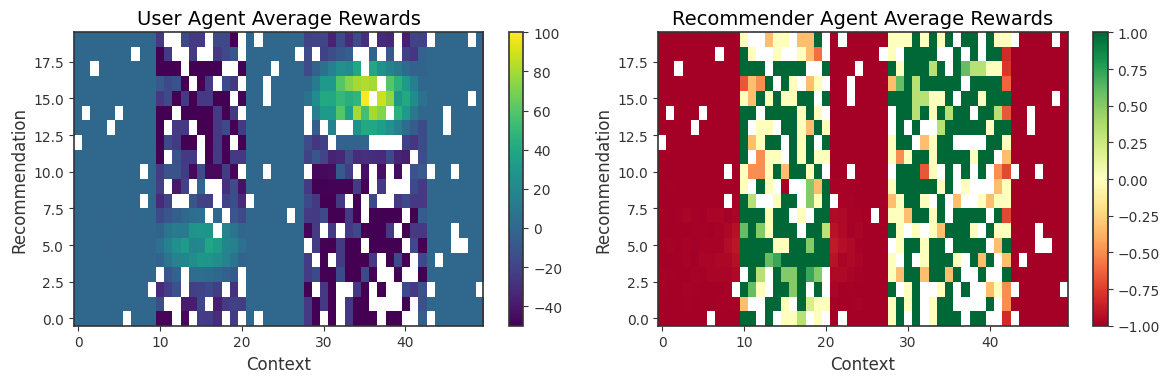

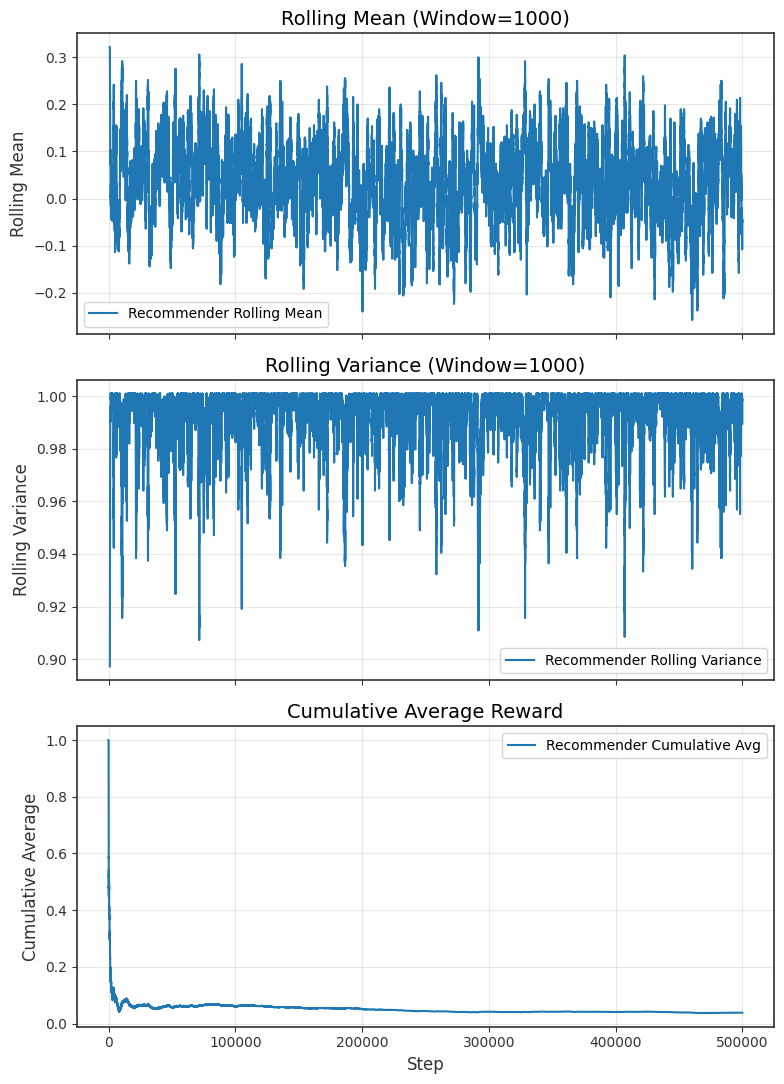

In [4]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=MoodSwings,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 500000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = True,
                                    initialize_recommended = True,
                                    landscape_type='default',
                                    stationarity=True, strategy='ucb', modulated = False)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])
# plot_environment_vs_agent(results["environment_state_space"], results["average_reward_map"])
plot_reward_statistics(results, rolling_window=1000)

reward_series = results["recommender_rewards"]
# ADF test on raw recommender reward sequence
# adf_stationarity_test(reward_series, name="Recommender Reward Signal")
# kpss_test(reward_series, name="Recommender Reward Signal")
# Run sliding window tests
# stationarity_df = rolling_stationarity_test(reward_series, window_size=1000, step_size=500)
# # Plot the p-values
# plot_rolling_stationarity_pvalues(stationarity_df, alpha=0.05, title_prefix="Recommender Reward: ")

# stationarity_df = test_stationarity_by_context(
#     contexts=results["context_history"],
#     rewards=results["recommender_rewards"])
# print(stationarity_df)

## Non-Stationary, Initiation, No Modulation



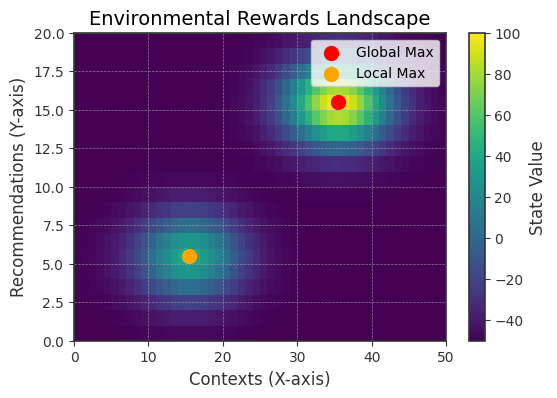

Running Simulation: 100%|██████████| 1000000/1000000 [01:22<00:00, 12084.21it/s]


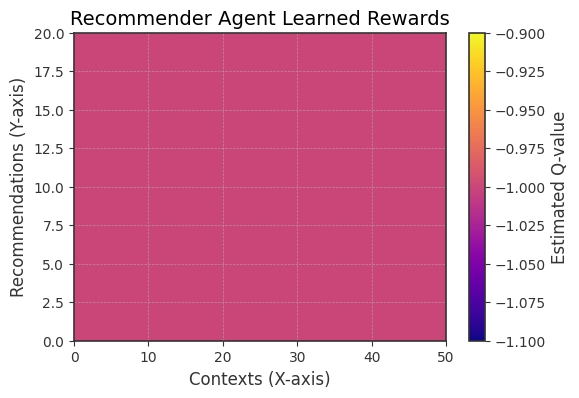

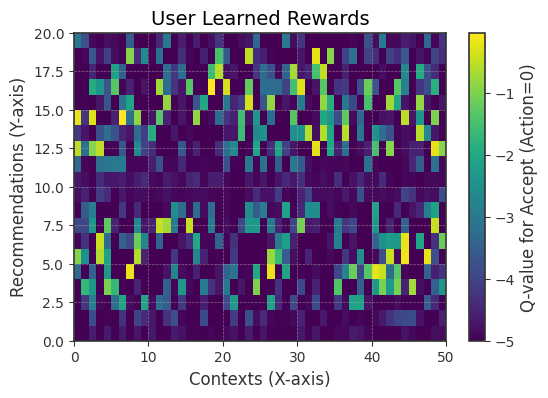

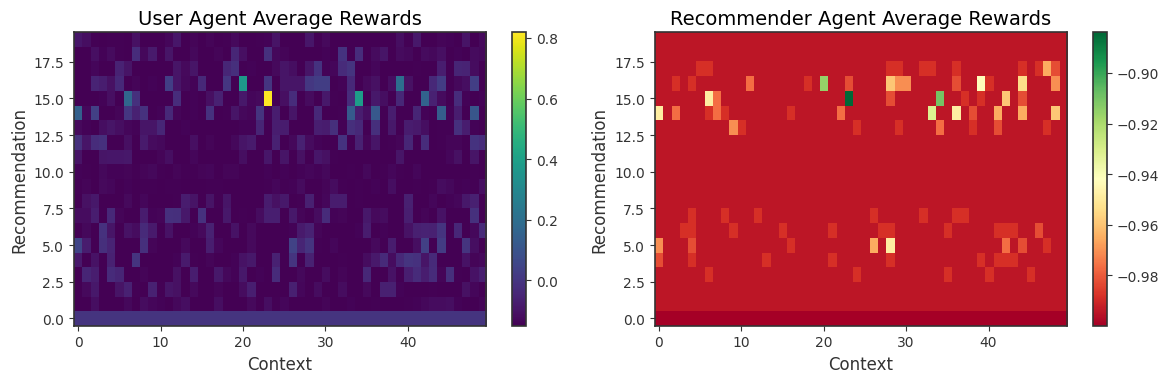

In [5]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=MoodSwings,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 1000000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = False,
                                    initialize_recommended= False,
                                    landscape_type='default',
                                    stationarity=False, strategy='ucb', modulated = False)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])

reward_series = results["recommender_rewards"]


## Stationary, Initiation, Moody Modulation

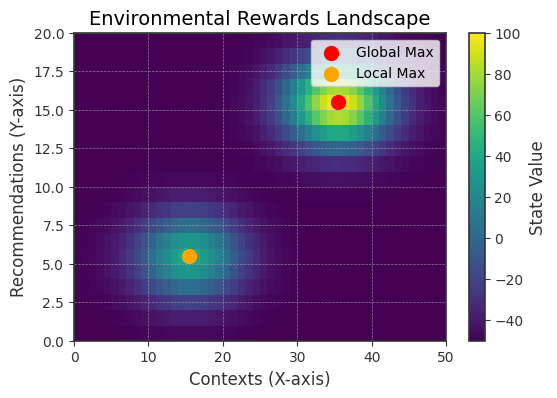

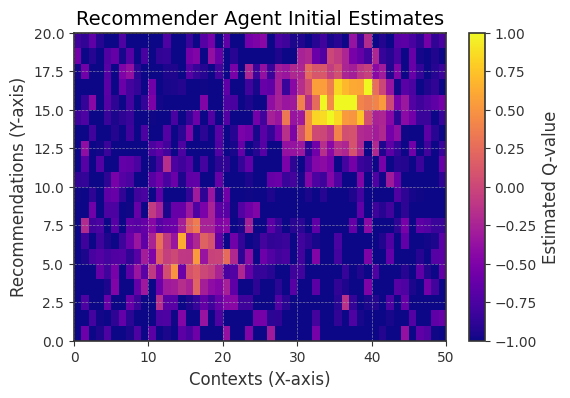

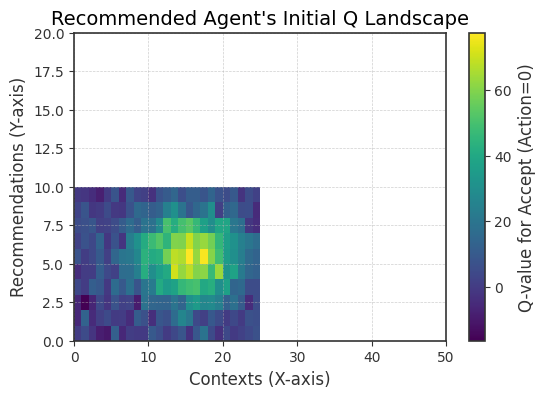

Running Simulation: 100%|██████████| 500000/500000 [00:50<00:00, 9820.64it/s] 


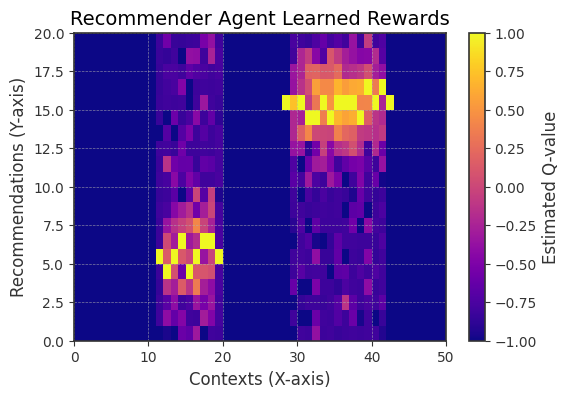

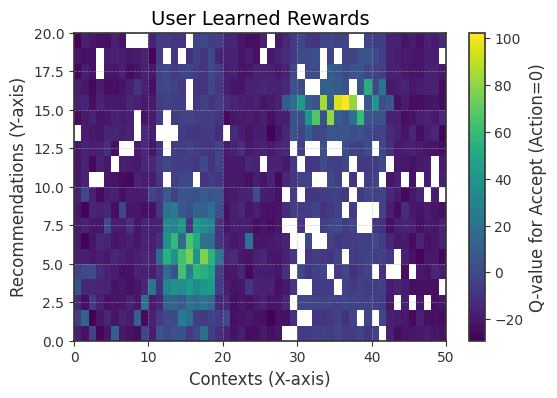

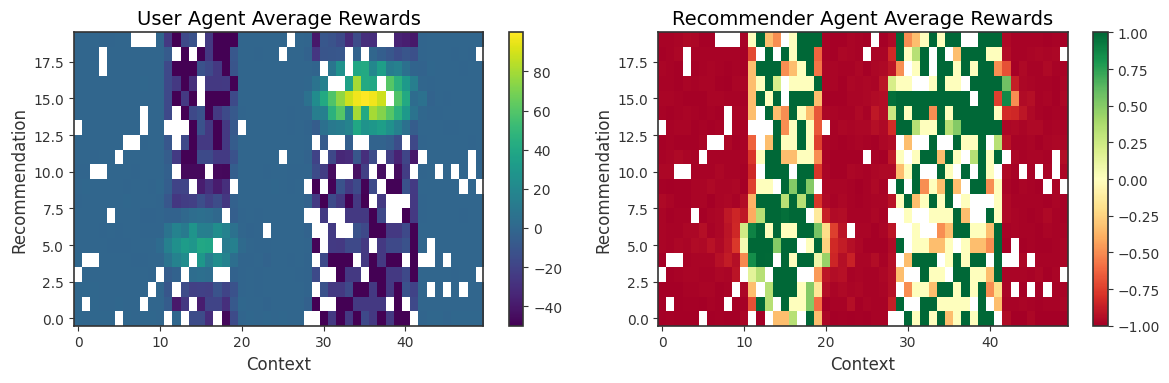

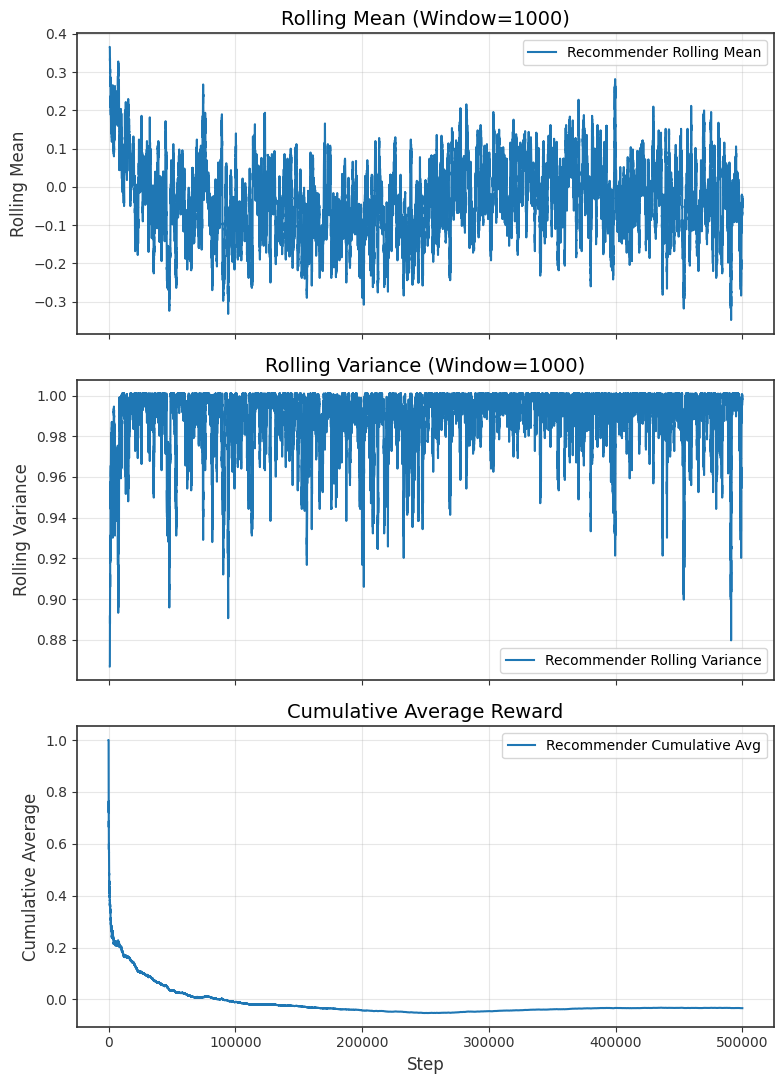

In [6]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=MoodSwings,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 500000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = True,
                                    initialize_recommended = True,
                                    landscape_type='default',
                                    stationarity=True, strategy='ucb', modulated = True)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])
# plot_environment_vs_agent(results["environment_state_space"], results["average_reward_map"])
plot_reward_statistics(results, rolling_window=1000)

reward_series = results["recommender_rewards"]

## Stationary, Initiation, Receptor Modulation

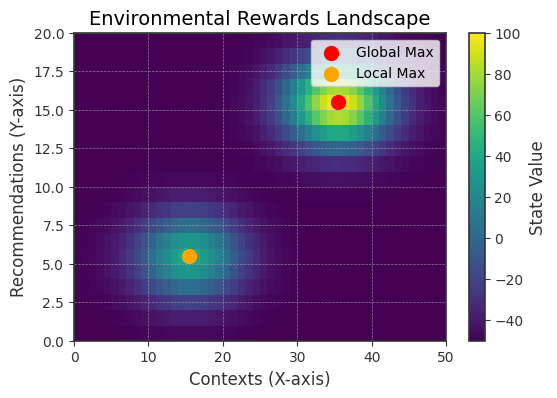

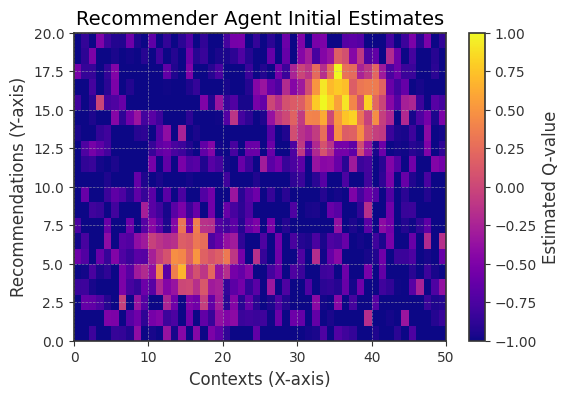

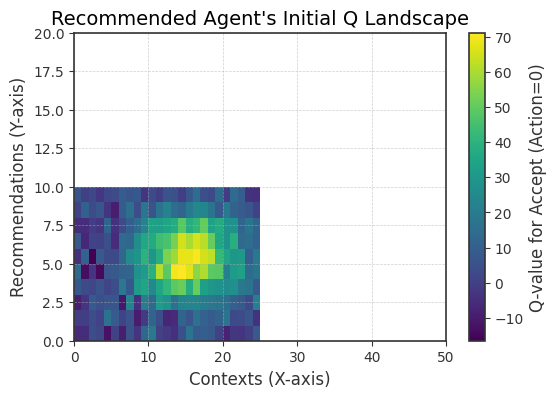

Running Simulation: 100%|██████████| 500000/500000 [00:38<00:00, 13073.75it/s]


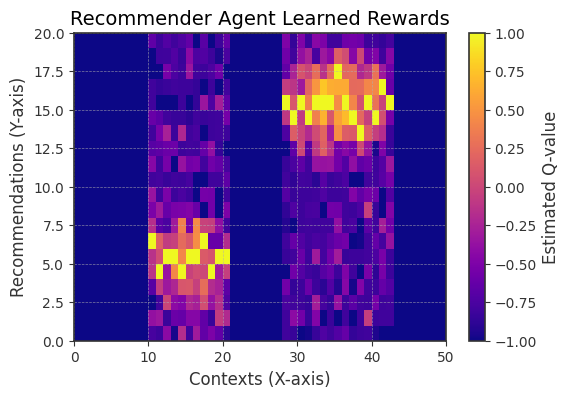

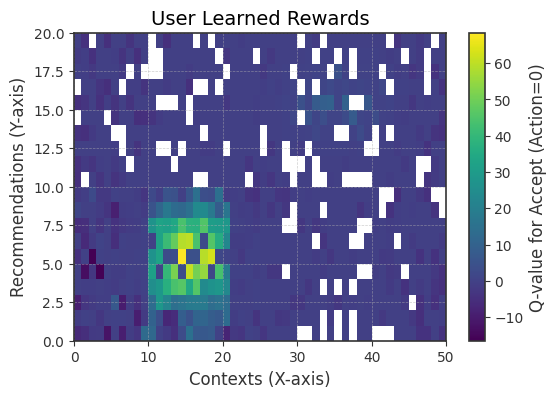

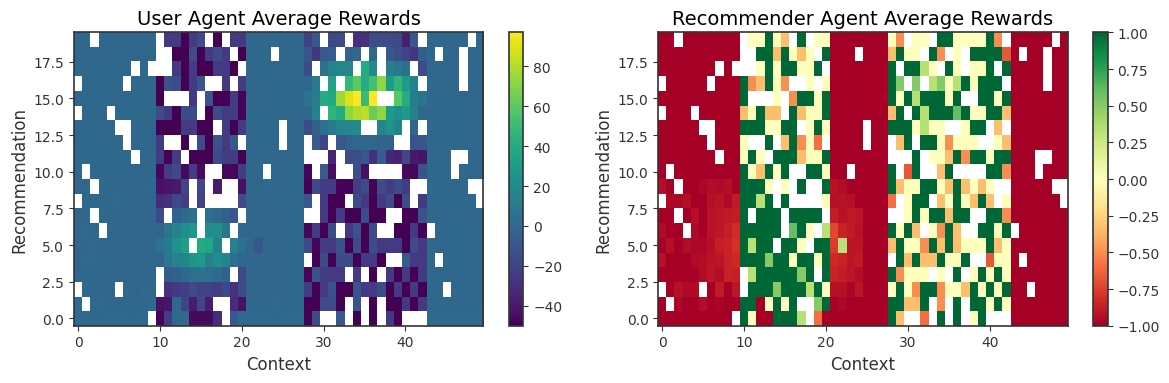

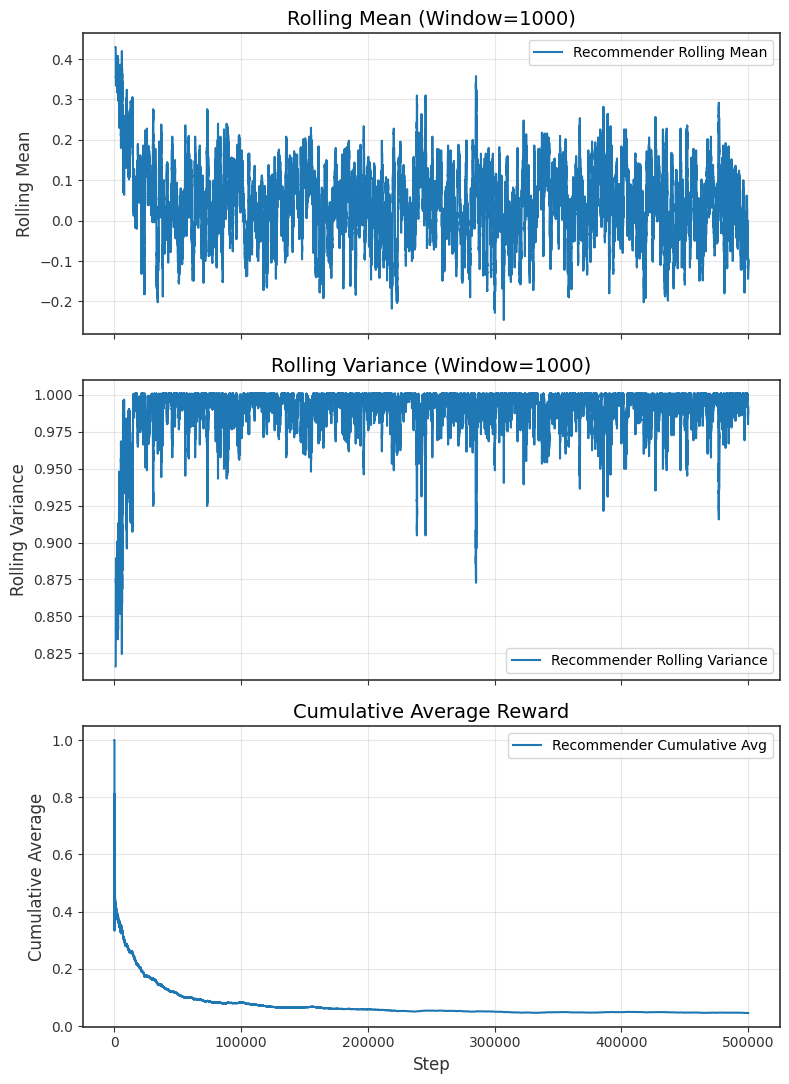

In [7]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=ReceptorModulator,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 500000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = True,
                                    initialize_recommended = True,
                                    landscape_type='default',
                                    stationarity=True, strategy='ucb', modulated = True)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])
# plot_environment_vs_agent(results["environment_state_space"], results["average_reward_map"])
plot_reward_statistics(results, rolling_window=1000)


## Stationary, Initiation, Receptor Modulation

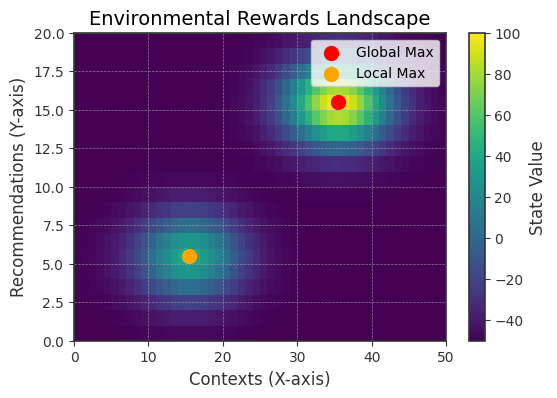

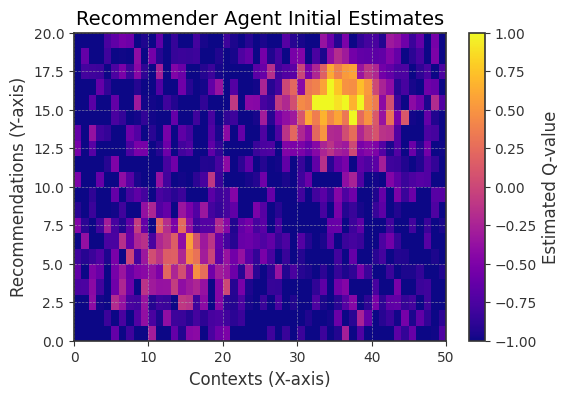

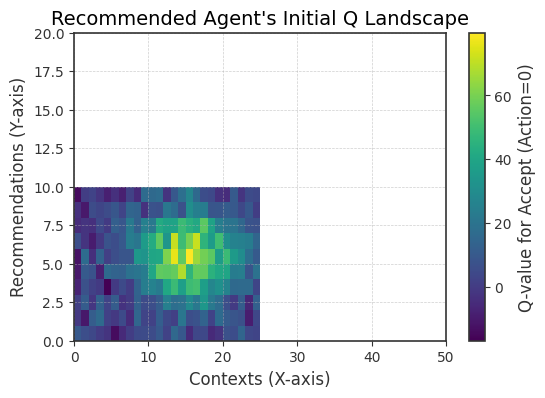

Running Simulation: 100%|██████████| 500000/500000 [00:36<00:00, 13777.30it/s]


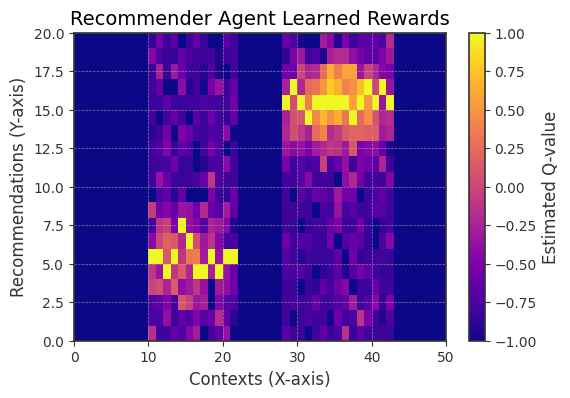

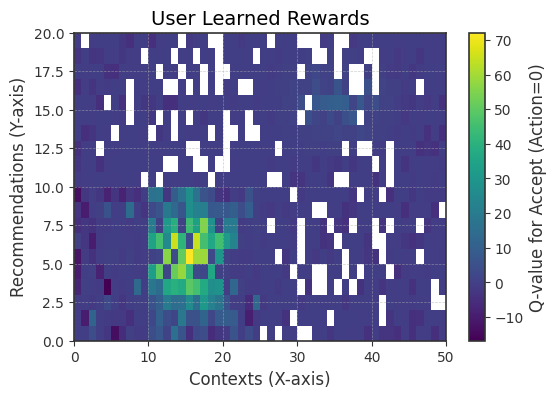

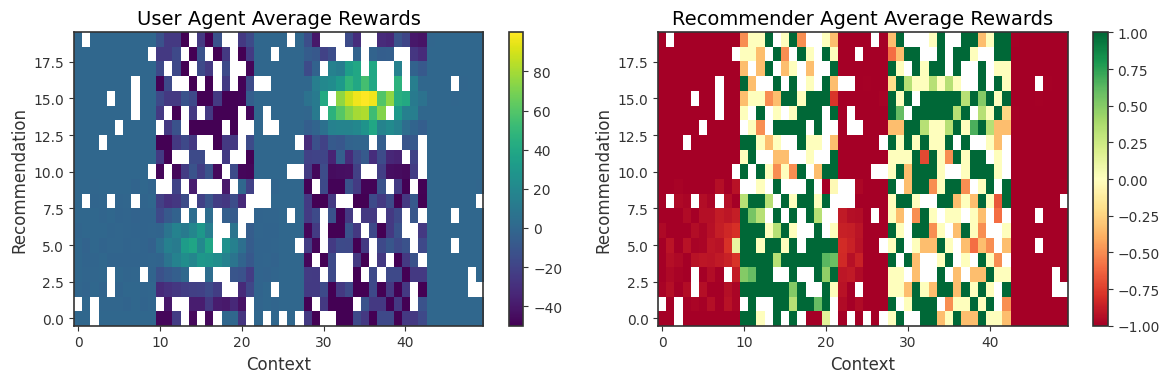

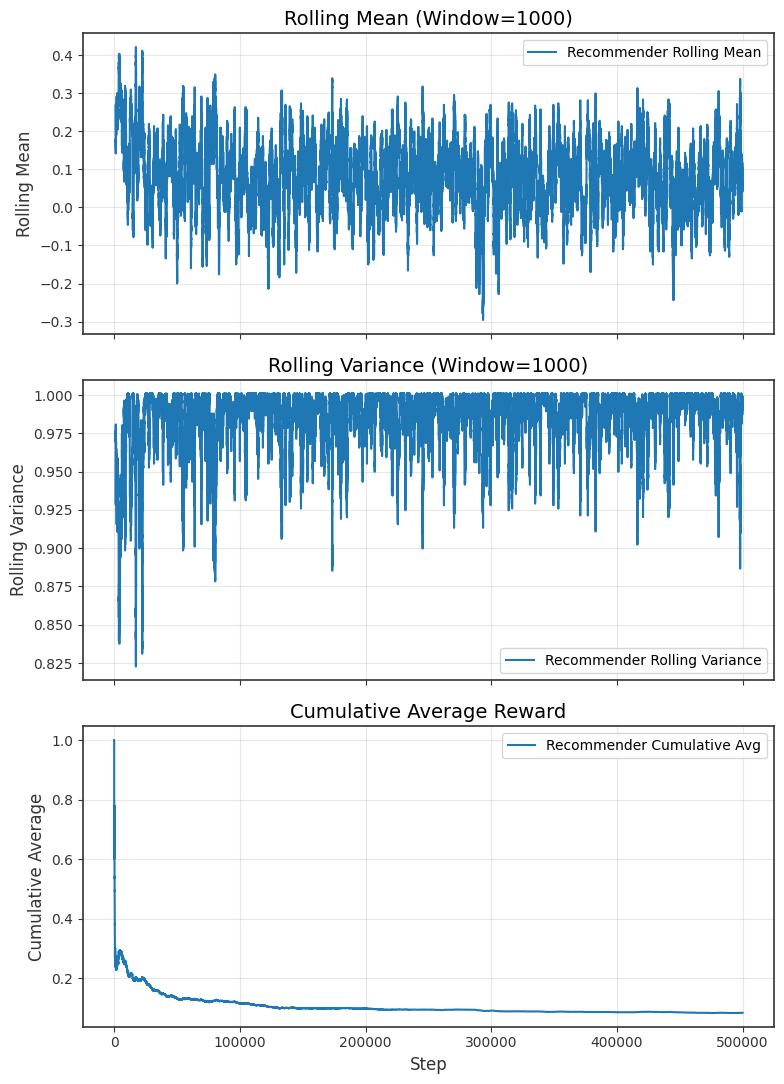

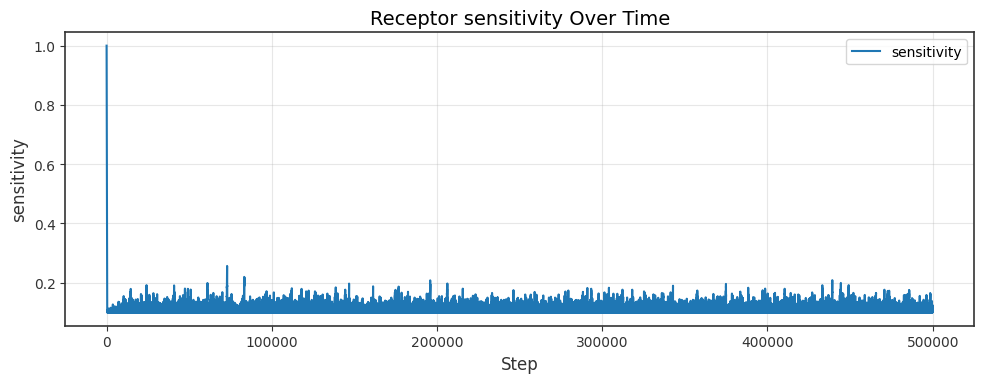

In [8]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=ReceptorModulator,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 500000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = True,
                                    initialize_recommended = True,
                                    landscape_type='default',
                                    stationarity=True, strategy='ucb', modulated = True)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])
# plot_environment_vs_agent(results["environment_state_space"], results["average_reward_map"])
plot_reward_statistics(results, rolling_window=1000)
modulator = results["modulator"]
plot_sensitivity(modulator)

## Stationary, Initiation, Novelty Modulation

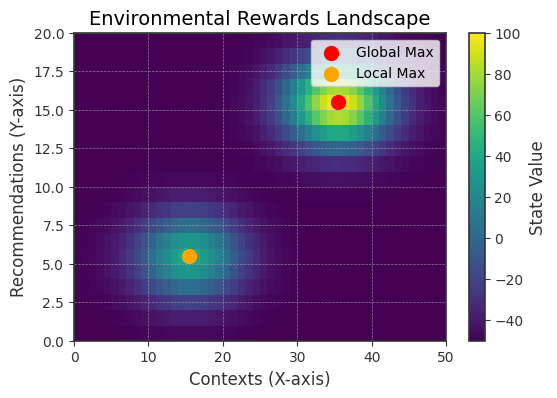

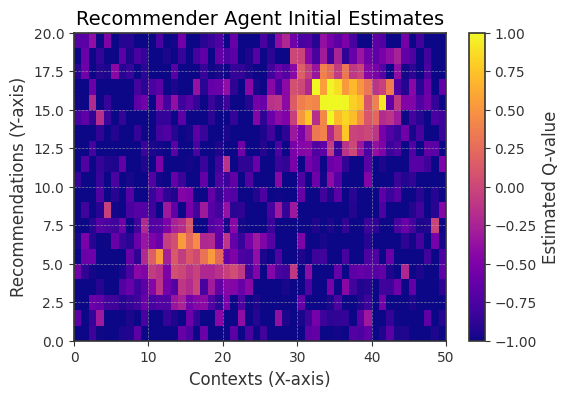

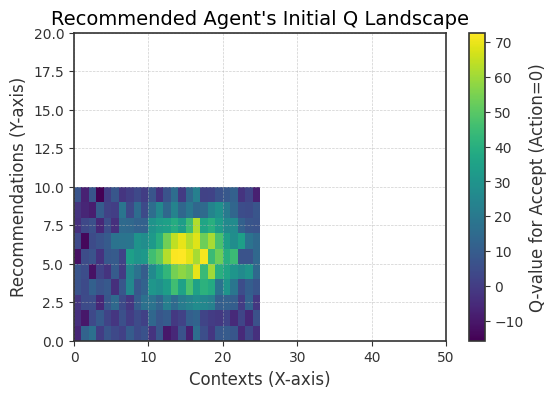

Running Simulation: 100%|██████████| 500000/500000 [00:31<00:00, 15746.04it/s]


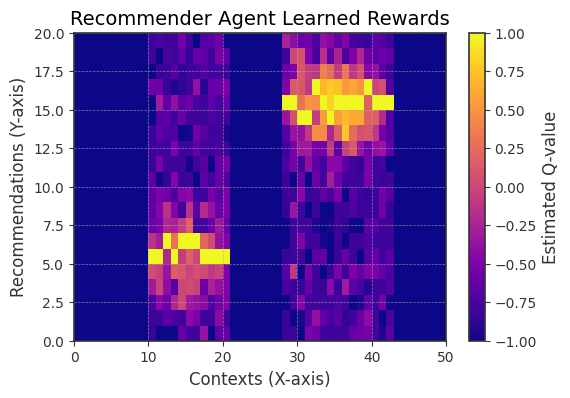

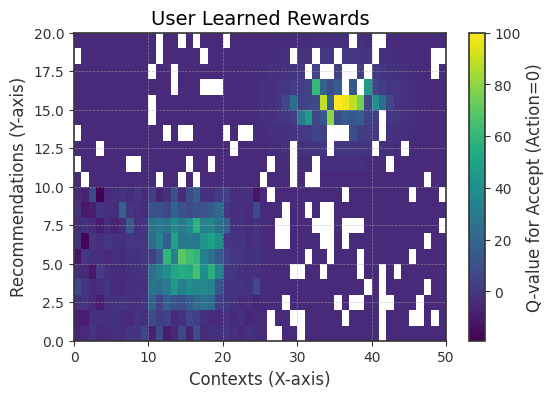

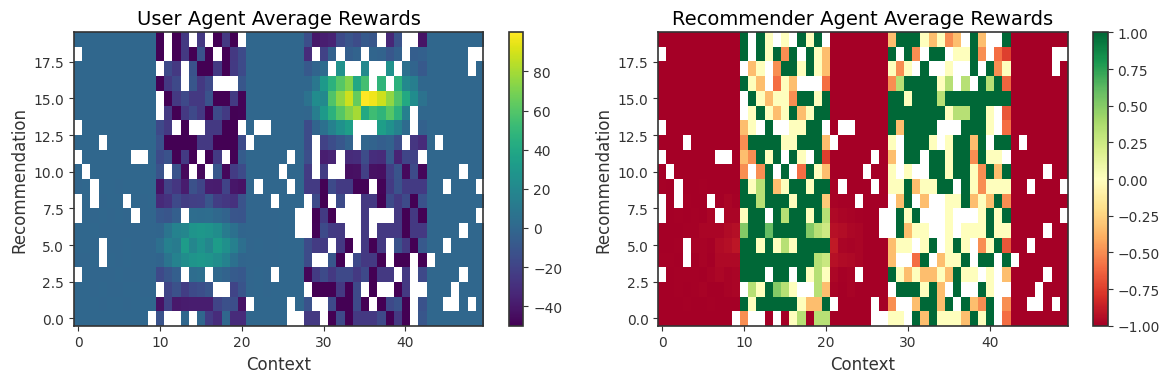

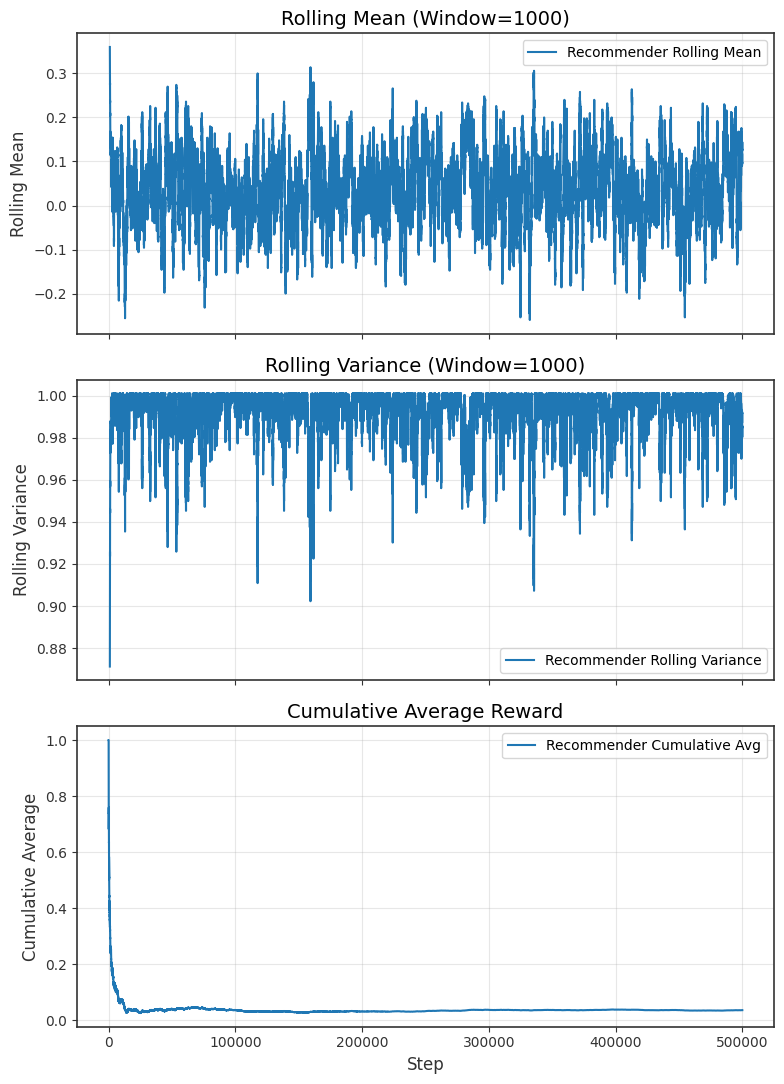

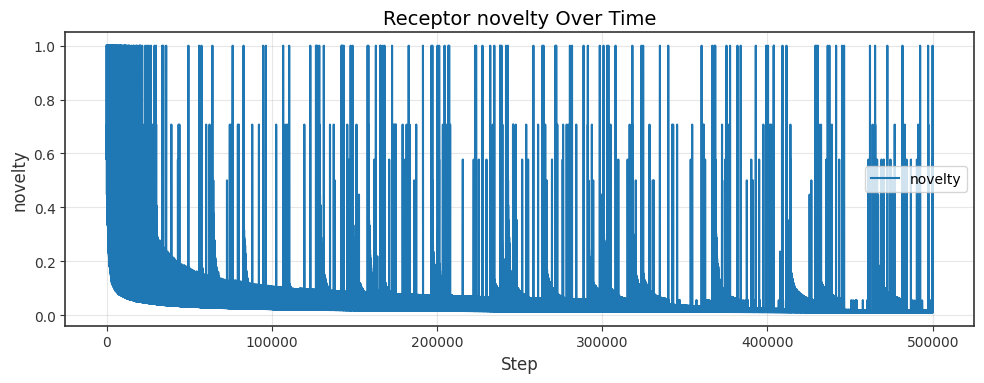

In [9]:
results = run_recommender_simulation(RecommenderAgent,
                                    RecommendedAgent,
                                    ExogenousRewardEnvironment,
                                    modulator_class=NoveltyModulator,
                                    n_recommendations=20,
                                    n_contexts=50,
                                    n_steps = 500000,
                                    exploration_rate=1,
                                    exploration_decay=0.999,
                                    initialize_recommender = True,
                                    initialize_recommended = True,
                                    landscape_type='default',
                                    stationarity=True, strategy='ucb', modulated = True)
plot_full_results(results["environment_state_space"], results["average_reward_map"], results["average_recommender_map"])
# plot_environment_vs_agent(results["environment_state_space"], results["average_reward_map"])
plot_reward_statistics(results, rolling_window=1000)
modulator = results["modulator"]
plot_sensitivity(modulator,variable='novelty')